### Step 1: Initialization & $\epsilon$-Soft Policy
We use a dictionary to store the Q-values because the state space in Blackjack is a tuple (player_sum, dealer_card, usable_ace).

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Initialize environment
env = gym.make('Blackjack-v1', sab=True)

# Data structures for Monte Carlo
Q = defaultdict(lambda: np.zeros(env.action_space.n))
returns_sum = defaultdict(lambda: np.zeros(env.action_space.n))
returns_count = defaultdict(lambda: np.zeros(env.action_space.n))

def get_epsilon_greedy_policy(state, Q, epsilon):
    """Implementation of epsilon-soft policy for exploration."""
    if np.random.random() > epsilon:
        return np.argmax(Q[state])
    else:
        return env.action_space.sample()

### Step 2: The Training Loop (500,000 Episodes)This implements First-Visit Monte Carlo Control. 
It collects a whole episode first, then works backwards to calculate the returns ($G$).

In [2]:
num_episodes = 500000
epsilon = 0.1
all_returns = []

for i in range(num_episodes):
    state, _ = env.reset()
    trajectory = []
    
    # 1. Generate an episode
    while True:
        action = get_epsilon_greedy_policy(state, Q, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        trajectory.append((state, action, reward))
        state = next_state
        if terminated or truncated:
            all_returns.append(reward)
            break
            
    # 2. First-Visit MC Update
    G = 0
    visited_state_actions = set()
    for s, a, r in reversed(trajectory):
        G = r + G  # Return G (gamma=1 for Blackjack)
        if (s, a) not in visited_state_actions:
            visited_state_actions.add((s, a))
            returns_sum[s][a] += G
            returns_count[s][a] += 1
            # Average the returns to update Q
            Q[s][a] = returns_sum[s][a] / returns_count[s][a]

print("Training Complete.")

Training Complete.


Step 3: Required 3D Surface Plots

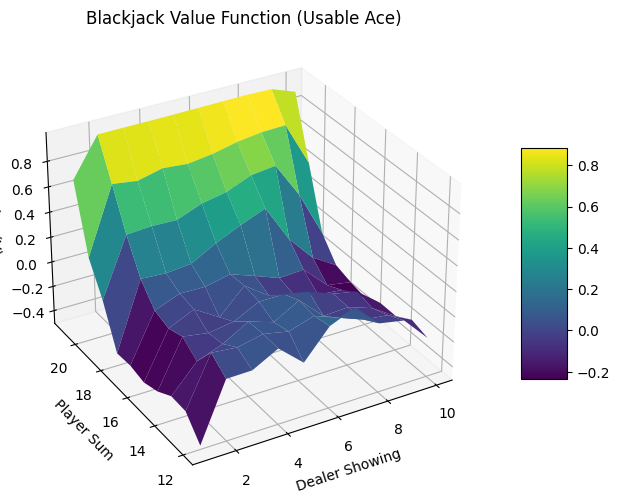

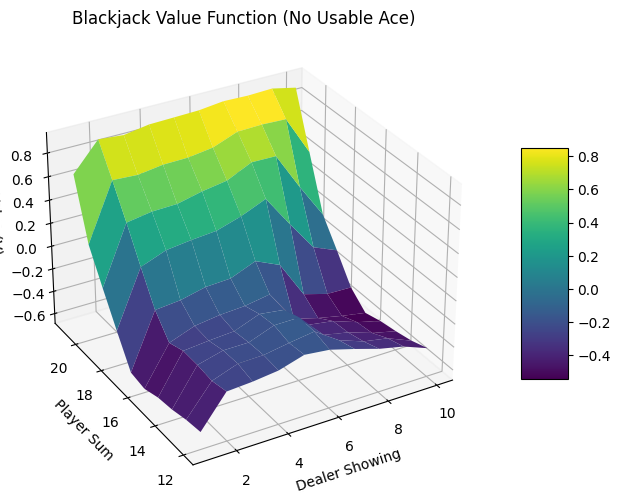

In [6]:
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

def plot_blackjack_value(Q, usable_ace=True):
    # 1. Define the ranges (Dealer showing 1-10, Player sum 12-21)
    dealer_showing = np.arange(1, 11)
    player_sum = np.arange(12, 22)
    X, Y = np.meshgrid(dealer_showing, player_sum)
    
    # 2. Manually build the Z matrix to avoid shape errors
    Z = np.zeros(X.shape)
    for i, p_sum in enumerate(player_sum):
        for j, d_card in enumerate(dealer_showing):
            # V(s) = max(Q(s, a))
            Z[i, j] = np.max(Q[(p_sum, d_card, usable_ace)])

    # 3. Create the 3D Plot
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap=cm.viridis, antialiased=True)
    
    ax.set_xlabel('Dealer Showing')
    ax.set_ylabel('Player Sum')
    ax.set_zlabel('Value (V)')
    ax.set_title(f"Blackjack Value Function ({'Usable' if usable_ace else 'No Usable'} Ace)")
    
    # Adjust viewing angle
    ax.view_init(elev=30, azim=-120)
    plt.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()

# Run the fixed plots
plot_blackjack_value(Q, usable_ace=True)
plot_blackjack_value(Q, usable_ace=False)

### Step 4: Learning Curve (Quantitative Support)
To get the "quantitative support" mentioned in your feedback, we need to show the agent is actually getting better.

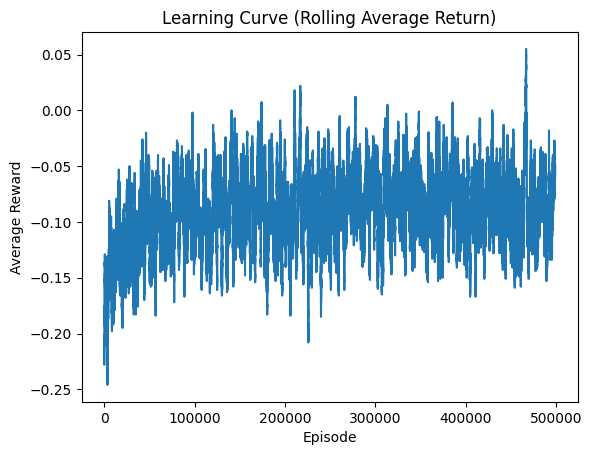

In [7]:
# Rolling average of rewards to show learning
rolling_avg = np.convolve(all_returns, np.ones(1000)/1000, mode='valid')
plt.plot(rolling_avg)
plt.title("Learning Curve (Rolling Average Return)")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.show()